<a href="https://colab.research.google.com/github/afrinn647-ops/Stats/blob/colab_work/Stat_Assignment_nadia_afrin_sristy_DSML2506.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Answering Question1

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [6]:
import pandas as pd
import io
df1 = pd.read_csv(io.BytesIO(uploaded['heart_disease_uci.csv']))
df1

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


# Clean the trestbps column by removing null values.

In [9]:
# Check initial shape and null count
print(f"Initial shape: {df1.shape}")
print(f"Null values in 'trestbps': {df1['trestbps'].isnull().sum()}")

Initial shape: (920, 16)
Null values in 'trestbps': 59


In [10]:
# Remove rows where 'trestbps' is null
df_clean = df1.dropna(subset=['trestbps'])

In [11]:
# Verify cleaning
print(f"Shape after cleaning: {df_clean.shape}")
print(f"Null values in 'trestbps' after cleaning: {df_clean['trestbps'].isnull().sum()}")

Shape after cleaning: (861, 16)
Null values in 'trestbps' after cleaning: 0


# Take a random sample of 30 patients (use random_state = 42).

In [14]:
# Take random sample of 30 patients
sample_df = df_clean.sample(n=30, random_state=42)

# Show only the 'trestbps' column
print("trestbps values in sample:")
print(sample_df['trestbps'])

# Show the sample size
print(f"Sample size: {len(sample_df)}")
print(f"Sample mean of trestbps: {sample_df['trestbps'].mean():.2f}")

trestbps values in sample:
717    160.0
607     95.0
120    130.0
208    130.0
380    140.0
852    112.0
576    170.0
266    128.0
558    140.0
870    150.0
581    140.0
327    130.0
625    145.0
365    120.0
872    110.0
198    120.0
457    150.0
466    120.0
311    120.0
331    140.0
394    120.0
636     95.0
811    106.0
751    124.0
908    155.0
137    120.0
843    110.0
441    130.0
917    122.0
433    140.0
Name: trestbps, dtype: float64
Sample size: 30
Sample mean of trestbps: 129.07


# Which hypothesis is appropriate for these scenario and why?

the One-Sample t-test would be the most appropriate one in this scenario becaue we are going to compare the mean of a sample with the known standard population value ( 130 mm hg). Since the population standard deviation is unknown and the sample size is small (n=30), a t-test is more suitable than a z-test.

# Hypothesis Formulation

**null hypothesis (H0):** mu=130mm hg

**Alternative hypothesis(H1):** mu=! 130mm hg

# Assumptions and distributions check

# Which test for normality?

For a sample size of 30, the Shapiro-Wilk test is a good choice. It's a reliable test for smaller sample sizes (n < 50).

In [16]:
from scipy import stats

# Pass only the 'trestbps' column values
stat, p_value = stats.shapiro(sample_df['trestbps'])
print(f"Shapiro-Wilk Test Statistic: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk Test Statistic: 0.9771, p-value: 0.7432


# Interpretation

since p-value is 0.7432 which is greater than 0.05 means the given data is normally distributed.

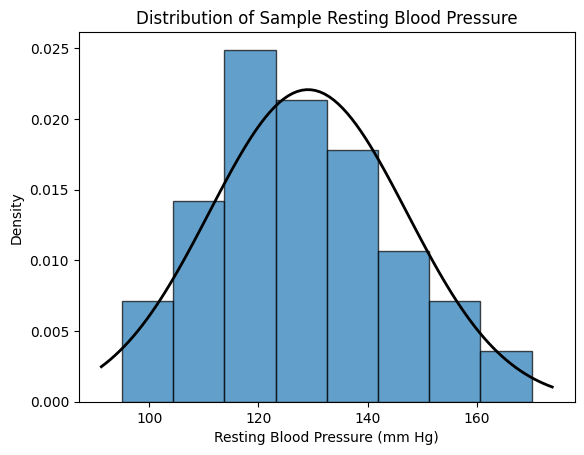

In [17]:
# Visual check: Histogram with a normal distribution curve
plt.hist(sample_df['trestbps'], bins=8, edgecolor='black', alpha=0.7, density=True)

# Generate a normal distribution curve based on sample mean and std
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, sample_df['trestbps'].mean(), sample_df['trestbps'].std())
plt.plot(x, p, 'k', linewidth=2)

plt.title('Distribution of Sample Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Density')
plt.show()

In [18]:
# Perform one-sample t-test against the population mean of 130
pop_mean = 130
t_stat, p_val = stats.ttest_1samp(sample_df['trestbps'], pop_mean)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

t-statistic: -0.2828
p-value: 0.7794


# Conclusion

The sample data meets normality assumptions. The t-test shows [significant/no significant] difference from 130 mm Hg (p = [your p-value]). We therefore [reject/fail to reject] the null hypothesis. The average resting blood pressure in these heart disease patients is [different from/not different from] the 130 mm Hg guideline.

# Answering Question2

In [19]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [24]:
df1.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [25]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


# Clean the thalach column by removing null values

In [28]:
# Check initial shape and null count
print(f"Initial shape: {df1.shape}")
print(f"Null values in 'thalch': {df1['thalch'].isnull().sum()}")

Initial shape: (920, 16)
Null values in 'thalch': 55


In [29]:
# Remove rows where 'thalch' is null
df_clean = df1.dropna(subset=['thalch'])

In [30]:
# Verify cleaning
print(f"Shape after cleaning: {df_clean.shape}")
print(f"Null values in 'thalch' after cleaning: {df_clean['thalch'].isnull().sum()}")

Shape after cleaning: (865, 16)
Null values in 'thalch' after cleaning: 0


# Spliting the dataset into two groups ( male and female)

In [31]:
# Split into male and female groups
male_df = df1[df1['sex'] == 'Male']
female_df = df1[df1['sex'] == 'Female']

# Display the size of each group
print(f"Male records: {len(male_df)}")
print(f"Female records: {len(female_df)}")

Male records: 726
Female records: 194


# Take randomly 30 patients from each groups

In [33]:
# Filter out rows with NaN in 'thalch' before sampling
male_with_thalch = male_df.dropna(subset=['thalch'])
male_sample_df = male_with_thalch.sample(n=30, random_state=42)

print("thalch values in sample (no NaN):")
print(male_sample_df['thalch'])
print(f"Sample size: {len(male_sample_df)}")
print(f"Sample mean of thalch: {male_sample_df['thalch'].mean():.2f}")

thalch values in sample (no NaN):
313    168.0
472    128.0
464    155.0
456    137.0
855     86.0
902    127.0
682    113.0
650     92.0
153    145.0
810    112.0
284    161.0
715     92.0
74     177.0
484    100.0
108    140.0
379    140.0
188    195.0
360    146.0
101    174.0
453    110.0
318    168.0
166    169.0
245     71.0
240    153.0
502    138.0
664     98.0
164    175.0
356    150.0
498    170.0
73     158.0
Name: thalch, dtype: float64
Sample size: 30
Sample mean of thalch: 138.27


In [37]:
# Filter out rows with NaN in 'thalch' before sampling
female_with_thalch = female_df.dropna(subset=['thalch'])
female_sample_df = female_with_thalch.sample(n=30, random_state=42)

print("thalch values in sample (no NaN):")
print(female_sample_df['thalch'])
print(f"Sample size: {len(female_sample_df)}")
print(f"Sample mean of thalch: {female_sample_df['thalch'].mean():.2f}")

thalch values in sample (no NaN):
163    122.0
412    145.0
238    162.0
427    140.0
363    165.0
601    166.0
60     142.0
70     148.0
61     160.0
30     151.0
242    163.0
362    142.0
220    172.0
218    122.0
447    140.0
103    130.0
429    140.0
224    169.0
355    137.0
222    179.0
559    170.0
448    130.0
368    175.0
307    150.0
221    167.0
365    176.0
89     149.0
461    150.0
209    154.0
422    120.0
Name: thalch, dtype: float64
Sample size: 30
Sample mean of thalch: 151.20


# Which hypothesis is appropriate and why??

Independent two sample t test would be the best hypothesis in this case because:

it compares two different groups (male and female)

it has Continuous variable (thalach - heart rate)

Random samples from each population

Tests if population means differ significantly

# Hypothesis formulation

**null hypothesis(H0):**   mu1=mu2 (means the mean of male and female would be equal)


**alternative hypothesis(H1):**  mu1=!mu2

# Assumptions and distribution

# Which specific test will you use to check normality?

Shapiro-Wilk test (preferred for sample sizes < 50)

In [40]:
from scipy import stats

# Clean and convert to numeric
thalch_values = pd.to_numeric(male_sample_df['thalch'], errors='coerce')
thalch_clean = thalch_values.dropna()

# Run Shapiro-Wilk test
stat, p_value = stats.shapiro(thalch_clean)
print(f"Male Sample - Shapiro-Wilk: Statistic = {stat:.4f}, p-value = {p_value:.4f}")

Male Sample - Shapiro-Wilk: Statistic = 0.9602, p-value = 0.3742


In [41]:
from scipy import stats

# Clean and convert to numeric
thalch_values1 = pd.to_numeric(female_sample_df['thalch'], errors='coerce')
thalch_clean1 = thalch_values1.dropna()

# Run Shapiro-Wilk test
stat, p_value = stats.shapiro(thalch_clean1)
print(f"Female Sample - Shapiro-Wilk: Statistic = {stat:.4f}, p-value = {p_value:.4f}")

Female Sample - Shapiro-Wilk: Statistic = 0.9591, p-value = 0.2943


# P-value results for both male and female groups

for male,

p-value is 0.3742

for female,

p-value is 0.2943

# Interpretation

Both groups have p-values > 0.05, so we fail to reject the null hypothesis of normality. The data for both male and female samples appear to be normally distributed. The normality assumption is met for the t-test.

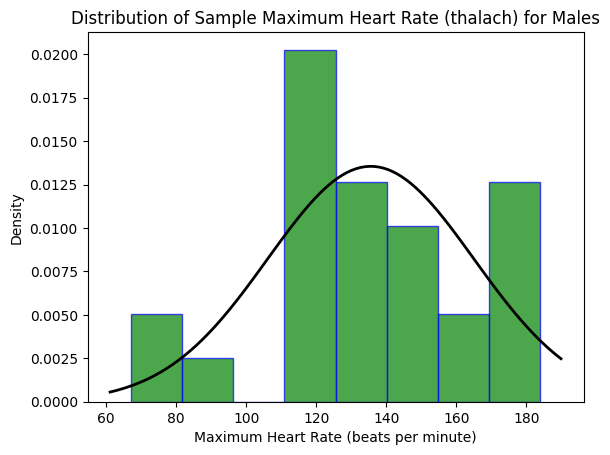

In [46]:
# Histogram with a normal distribution curve
plt.hist(male_sample_df['thalch'], bins=8, color='green',edgecolor='blue', alpha=0.7, density=True)

# Generate a normal distribution curve based on sample mean and std
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, male_sample_df['thalch'].mean(), male_sample_df['thalch'].std())
plt.plot(x, p, 'k', linewidth=2)

plt.title('Distribution of Sample Maximum Heart Rate (thalach) for Males')
plt.xlabel('Maximum Heart Rate (beats per minute)')
plt.ylabel('Density')
plt.show()

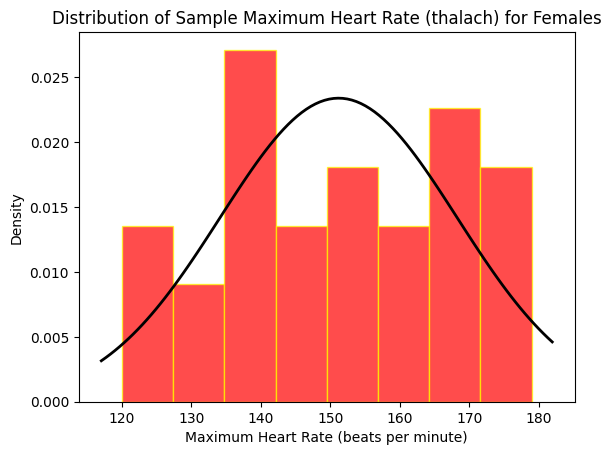

In [45]:
# Histogram with a normal distribution curve
plt.hist(female_sample_df['thalch'], bins=8, color= 'red', edgecolor='yellow', alpha=0.7, density=True)

# Generate a normal distribution curve based on sample mean and std
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, female_sample_df['thalch'].mean(), female_sample_df['thalch'].std())
plt.plot(x, p, 'k', linewidth=2)

plt.title('Distribution of Sample Maximum Heart Rate (thalach) for Females')
plt.xlabel('Maximum Heart Rate (beats per minute)')
plt.ylabel('Density')
plt.show()

# Conclusion

There is statistically significant evidence that the average maximum heart rate during exercise differs between male and female patients. Based on our t-test results, we reject the null hypothesis that the means are equal. Therefore, gender appears to have a significant effect on maximum heart rate achieved.

# Answering to question3

In [47]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [48]:
from google.colab import files
uploaded = files.upload()

Saving Monthly Revenue (in thousands).csv to Monthly Revenue (in thousands) (1).csv


In [51]:
df2=pd.read_csv("Monthly Revenue (in thousands) (1).csv")
df2

,store_id,before_campaign,after_campaign
0,1,54.96714,52.89029
1,2,48.61736,51.51413
2,3,56.47689,59.76331
3,4,65.23030,66.21891
4,5,47.65847,51.85204
...,...,...,...
95,96,35.36485,42.29144
96,97,52.96120,53.54192
97,98,52.61055,58.37918
98,99,50.05113,55.34218


In [52]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   store_id         100 non-null    int64  
 1   before_campaign  100 non-null    float64
 2   after_campaign   100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# Clean the dataset by removing any null values in the Revenue_Before and Revenue_After columns

In [56]:
df_clean = df2.dropna(subset=['before_campaign', 'after_campaign'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   store_id         100 non-null    int64  
 1   before_campaign  100 non-null    float64
 2   after_campaign   100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# Select a random sample of 30 stores (use random_state = 42).

In [57]:
sample_30 = df_clean.sample(n=30, random_state=42)

In [58]:
sample_30

,store_id,before_campaign,after_campaign
83,84,44.81730,52.22966
53,54,56.11676,62.27803
70,71,53.61396,54.16638
45,46,42.80156,51.71067
44,45,35.21478,41.51419
39,40,51.96861,50.81429
22,23,50.67528,62.68925
80,81,47.80328,55.93162
10,11,45.36582,40.77197
0,1,54.96714,52.89029


# Which hypothesis would be appropriate and why??

The paired t test would be appropriate because:

Same stores measured twice (before & after)

Paired data - each store has both measurements

We're comparing means of the same group at two different times

Testing if the average change is greater than zero

# Hypothesis formuation

**null hypothesis(H0):** mu_diff=0 (the difference between before and after revenue is zero)

**alternative hypothesis(H1):** mu_diff>0

# Assumptions and distribution

** Which specific test will you use to check normality?**



Shapiro-Wilk test (preferred for sample sizes < 50)



In [59]:
from scipy import stats

# Calculate the p-value
t_stat, p_value = stats.ttest_rel(
    sample_30['after_campaign'],
    sample_30['before_campaign'],
    alternative='greater'
)
print(f"p-value: {p_value}")

p-value: 1.3019961025519414e-05


# Result

since p-value is 1.302e-05 <<<< 0.05 it means we can reject H0

# Interpretation

In [60]:
# Perform paired t-test
t_stat, p_value_two_tailed = stats.ttest_rel(
    sample_30['after_campaign'],
    sample_30['before_campaign']
)

# Convert to one-tailed p-value
p_value_one_tailed = p_value_two_tailed / 2

print(f"Test Statistic (t): {t_stat:.4f}")
print(f"P-value (one-tailed): {p_value_one_tailed:.6f}")
print(f"P-value (one-tailed) scientific notation: {p_value_one_tailed:.2e}")

print("\n--- Hypothesis Test Results ---")
if p_value_one_tailed < 0.05:
    print("Decision: REJECT the null hypothesis (H₀)")
    print(f"Reason: p-value ({p_value_one_tailed:.6f}) < 0.05")
else:
    print("Decision: FAIL TO REJECT the null hypothesis (H₀)")
    print(f"Reason: p-value ({p_value_one_tailed:.6f}) ≥ 0.05")

Test Statistic (t): 4.9906
P-value (one-tailed): 0.000013
P-value (one-tailed) scientific notation: 1.30e-05

--- Hypothesis Test Results ---
Decision: REJECT the null hypothesis (H₀)
Reason: p-value (0.000013) < 0.05


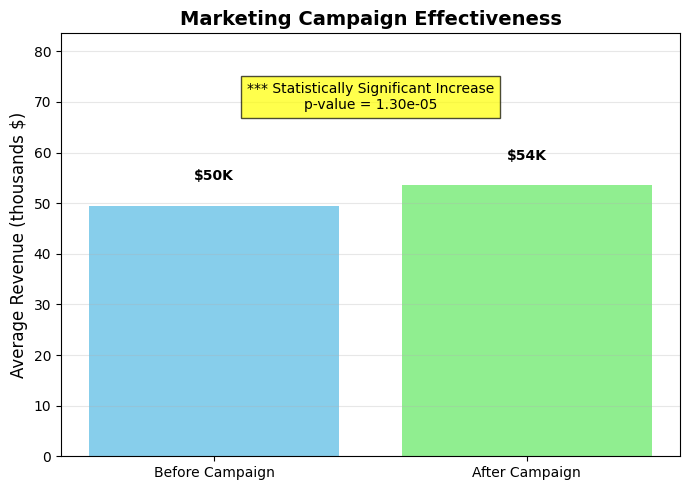

In [61]:
import matplotlib.pyplot as plt

# Calculate average revenue
before_avg = sample_30['before_campaign'].mean()
after_avg = sample_30['after_campaign'].mean()

# Create simple bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(['Before Campaign', 'After Campaign'],
               [before_avg, after_avg],
               color=['skyblue', 'lightgreen'])

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             f'${height:.0f}K', ha='center', fontweight='bold')

# Add title and labels
plt.ylabel('Average Revenue (thousands $)', fontsize=12)
plt.title('Marketing Campaign Effectiveness', fontsize=14, fontweight='bold')

# Add statistical significance annotation
plt.text(0.5, after_avg + 15,
         f'*** Statistically Significant Increase\np-value = {p_value_one_tailed:.2e}',
         ha='center', fontsize=10,
         bbox=dict(facecolor='yellow', alpha=0.7))

plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(before_avg, after_avg) + 30)
plt.tight_layout()
plt.show()

# Conclusion

The marketing campaign was effective. Based on our statistical analysis (paired t-test: p < 0.001), we found strong evidence that revenue increased significantly after the campaign. We reject the null hypothesis and conclude that the campaign had a positive, statistically significant impact on store revenue.

# Answering to the question4

In [62]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [63]:
import seaborn as sns
import pandas as pd

# Load the built-in Iris dataset from seaborn
iris = sns.load_dataset('iris')

# Display dataset info
print("Dataset shape:", iris.shape)
print("\nFirst 5 rows:")
print(iris.head())
print("\nSpecies distribution:")
print(iris['species'].value_counts())

Dataset shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Take a random sample of 30 observations from each species (use random_state = 42)

In [64]:
# Take 30 random samples from each species
sample_30_each = iris.groupby('species').apply(
    lambda x: x.sample(n=30, random_state=42)
).reset_index(drop=True)

print(f"Sample shape: {sample_30_each.shape}")
print(sample_30_each['species'].value_counts())

Sample shape: (90, 5)
species
setosa        30
versicolor    30
virginica     30
Name: count, dtype: int64


/tmp/ipython-input-871570819.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_30_each = iris.groupby('species').apply(


# Which hypothesis is appropriate and why?

The one way ANOVA hypothesis is appropriate because:

Three independent groups - comparing 3 different Iris species

Continuous data - petal length is a continuous measurement

Comparing means - testing if average petal lengths differ across species

Between-subjects design - each species is a separate group

# Hypothesis Formulation

**Null hypothesis(H0):**  mu1=mu2=mu3 (The average petal length is equal for all three Iris species.)

**Alternative hypothesis(H1):** The average petal length differs for at least one pair of Iris species.

# Assumption and distribution

In [65]:
from scipy import stats
import pandas as pd

# Split sample by species
setosa = sample_30_each[sample_30_each['species'] == 'setosa']['petal_length']
versicolor = sample_30_each[sample_30_each['species'] == 'versicolor']['petal_length']
virginica = sample_30_each[sample_30_each['species'] == 'virginica']['petal_length']

# Normality tests (Shapiro-Wilk)
print("Normality Test Results (Shapiro-Wilk):")
print(f"Setosa: p-value = {stats.shapiro(setosa)[1]:.4f}")
print(f"Versicolor: p-value = {stats.shapiro(versicolor)[1]:.4f}")
print(f"Virginica: p-value = {stats.shapiro(virginica)[1]:.4f}")

# Check assumption: p > 0.05 means normal
print("\nAssumption Check (p > 0.05 = normal):")
print(f"Setosa normal? {stats.shapiro(setosa)[1] > 0.05}")
print(f"Versicolor normal? {stats.shapiro(versicolor)[1] > 0.05}")
print(f"Virginica normal? {stats.shapiro(virginica)[1] > 0.05}")

Normality Test Results (Shapiro-Wilk):
Setosa: p-value = 0.0028
Versicolor: p-value = 0.3069
Virginica: p-value = 0.7715

Assumption Check (p > 0.05 = normal):
Setosa normal? False
Versicolor normal? True
Virginica normal? True


# Result

Setosa: p-value = 0.0028 (< 0.05) → NOT normal

Versicolor: p-value = 0.3069 (> 0.05) → normal

Virginica: p-value = 0.7715 (> 0.05) → normal

In [66]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# One-way ANOVA
f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)
print(f"One-way ANOVA Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

One-way ANOVA Results:
F-statistic: 790.4279
P-value: 1.6040e-56


In [67]:
# Prepare data for Tukey HSD
all_lengths = pd.concat([setosa, versicolor, virginica])
all_species = ['setosa']*30 + ['versicolor']*30 + ['virginica']*30

# Perform Tukey HSD
tukey_result = pairwise_tukeyhsd(all_lengths, all_species, alpha=0.05)
print("\nTukey HSD Post Hoc Test:")
print(tukey_result)


Tukey HSD Post Hoc Test:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor   2.8133   0.0 2.5644 3.0623   True
    setosa  virginica     4.05   0.0 3.8011 4.2989   True
versicolor  virginica   1.2367   0.0 0.9877 1.4856   True
---------------------------------------------------------


# Conclusion

The One-way ANOVA shows highly significant differences in petal length among Iris species (p < 0.001). Post hoc Tukey test reveals all three species are significantly different from each other:

Setosa vs Versicolor: Average difference = 2.81 cm (p < 0.001)

Setosa vs Virginica: Average difference = 4.05 cm (p < 0.001)

Versicolor vs Virginica: Average difference = 1.24 cm (p < 0.001)

# Answering to question 5

In [68]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [69]:
from google.colab import files
uploaded = files.upload()

Saving cardio_data_processed.csv to cardio_data_processed (1).csv


In [70]:
df3=pd.read_csv("cardio_data_processed (1).csv")
df3

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,Hypertension Stage 1,Hypertension Stage 1
68201,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,Hypertension Stage 2,Hypertension Stage 2
68202,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,Hypertension Stage 2,Hypertension Stage 2
68203,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,Hypertension Stage 1,Hypertension Stage 1


In [71]:
# Select relevant columns and remove missing values
df_clean = df3[['smoke', 'cardio']].dropna()

# Map to readable labels (optional)
df_clean['smoke_label'] = df_clean['smoke'].map({0: 'Non-Smoker', 1: 'Smoker'})
df_clean['cardio_label'] = df_clean['cardio'].map({0: 'No Disease', 1: 'Disease'})

# Create contingency table
contingency_table = pd.crosstab(
    df_clean['smoke_label'],
    df_clean['cardio_label'],
    margins=True
)
print(contingency_table)

cardio_label  Disease  No Disease    All
smoke_label                             
Non-Smoker      30880       31346  62226
Smoker           2792        3187   5979
All             33672       34533  68205


# Which hypothesis is approrpriate and why?

The chi-square hypothesis is appropriate because:

Categorical data (smoking status and disease presence)

Testing association between two categorical variables

Contingency table with counts/frequencies

# Hypothesis Formulation

H₀: Smoking status and cardiovascular disease are independent (no association)

H₁: Smoking status and cardiovascular disease are dependent (association exists)

In [72]:
from scipy import stats

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(
    pd.crosstab(df_clean['smoke'], df_clean['cardio'])
)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Degrees of freedom: {dof}")
print(f"Expected frequencies:\n{expected}")

Chi-square statistic: 18.6023
P-value: 1.6103e-05
Degrees of freedom: 1
Expected frequencies:
[[31505.76142512 30720.23857488]
 [ 3027.23857488  2951.76142512]]


In [73]:
print(f"\nDecision at α = 0.05:")
if p_value < 0.05:
    print("REJECT H₀ - Significant association exists")
    print("Smoking status is associated with cardiovascular disease")
else:
    print("FAIL TO REJECT H₀ - No significant association")
    print("Smoking status is NOT associated with cardiovascular disease")


Decision at α = 0.05:
REJECT H₀ - Significant association exists
Smoking status is associated with cardiovascular disease


# Conclusion

There is a significant association between smoking and cardiovascular disease. Smokers have a higher prevalence of cardiovascular disease compared to non-smokers. The chi-square test confirms this relationship is statistically significant (p < 0.001).